# 05 - ML Risk Scoring (Layer 1) + Policy Engine (Layer 2)

Notebook ini membangun arsitektur **2 layer** untuk menggantikan bagian
*scoring* dari 7-agent rule-based pipeline dengan Machine Learning, sambil
mempertahankan logika penurunan keputusan bisnis sebagai rule/policy engine:

- **Layer 1 (ML)** — model regresi yang memprediksi `risk_score` (0-1)
  langsung dari fitur mentah nasabah, tanpa diberi tahu rumus manual
  (bobot 5C / threshold) — belajar pola, bukan meniru formula.
- **Layer 2 (Policy Engine, tetap rule-based)** — fungsi yang mengambil
  `risk_score` (kini dari ML) lalu menentukan `decision`, `zone`, jenis
  kredit, nominal, tenor, bunga, dan insight — **logika ini TIDAK diganti
  ML**, karena semuanya turunan deterministik dari `risk_score`.

## Temuan penting sebelum notebook ini dibuat

Eksplorasi repo menemukan bahwa ada **dua implementasi rule-pipeline yang
berbeda dan tidak sinkron**:

1. **"Definisi A"** — fungsi `risk_agent()` di
   `notebooks/02_prepro&eda fix.ipynb`, yang menghasilkan
   `data/processed/master_scored.csv` (bobot Character .35/Financial .25/
   Collateral .20/Cashflow .10/Condition .10, threshold 0.70/0.55/0.40,
   bunga 9.5/12.0/15.0).
2. **"Definisi B"** — `utils/agent_pipeline.py`, yang live di
   `app.py`/`pages/*.py` sekarang (bobot .30/.30/.20/.20 tanpa komponen
   industri, threshold 0.75/0.60/0.45, bunga 10.0/13.0). Ini adalah rewrite
   independen yang dibuat belakangan untuk dashboard Streamlit.

Notebook ini melatih Layer 1 memakai `risk_score` dari **Definisi A**
(karena itulah yang tersimpan di `master_scored.csv`), sehingga **Layer 2**
di sini juga mem-port ulang threshold/bobot/aturan Definisi A — BUKAN
`utils/agent_pipeline.py`. Ini keputusan yang sudah dikonfirmasi eksplisit
ke pemilik project, karena angka `decision`/`zone`/`bunga_persen` yang
dihasilkan pipeline ML+rule ini akan **berbeda** dari yang live di
dashboard saat ini (yang masih pakai Definisi B) sampai ada keputusan
lanjutan untuk mengganti `utils/agent_pipeline.py`.

## Temuan soal artifact ML lama di `models/`

`models/credit_model.pkl` + `preprocessor.pkl` + `model_meta.pkl` (dari
`03_model_training.ipynb`) **tidak dipakai ulang di notebook ini** karena:
tugasnya beda (memprediksi `label` biner dari generator, bukan `risk_score`
kontinu), fitur-nya memakai `owner_gender`/`owner_marital_status` (flag
fair-lending), pipeline join-nya independen dari `master_dataset.csv`, dan
artifact-nya tidak pernah benar-benar dipanggil dari `app.py`/
`utils/agent_pipeline.py` mana pun (dicek via grep — nol referensi).
`models/model_card.md` juga kosong. Kesimpulan: retrain dari nol untuk
target `risk_score`.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score
from xgboost import XGBRegressor
import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_DIR = "../data/processed"
MODEL_DIR = "../models"

print("Libraries OK")

Libraries OK


## Tahap 1 — Load & Join Target

`risk_score` (target Layer 1) ada di `master_scored.csv`, sedangkan fitur
mentah ada di `master_dataset.csv`. Keduanya di-join lewat `application_id`
(sudah dicek 1:1, 3.000 baris di kedua file, tidak ada yang hilang).

In [6]:
master = pd.read_csv(f"{DATA_DIR}/master_dataset.csv", dtype={"NIK": str})
scored = pd.read_csv(f"{DATA_DIR}/master_scored.csv", dtype={"NIK": str})

df = master.merge(scored[["application_id", "risk_score", "decision"]], on="application_id", how="inner")
print("master_dataset:", master.shape, "| master_scored:", scored.shape, "| joined:", df.shape)
assert df["application_id"].is_unique
assert len(df) == len(master) == len(scored)

master_dataset: (3000, 83) | master_scored: (3000, 44) | joined: (3000, 85)


## Tahap 2 — Filter Baris Hard-Rule

`risk_agent()` (Definisi A) punya 3 kill-switch yang membuat `risk_score`
langsung `None` dan `decision` otomatis `"Tidak Layak"`, TANPA melalui
weighted scoring:

1. `identity_passed == False` (NIK/usia tidak valid)
2. `dhn_blacklisted == True` (status_dhn == "Ya")
3. `character_score == 0.0` (kolektibilitas SLIK terburuk = Macet)

Baris-baris ini **dibuang dari training set** — `risk_score`-nya bukan hasil
scoring bertingkat yang informatif, jadi kalau ikut dilatih, model hanya
belajar untuk selalu memprediksi angka kosong/ekstrem pada pola yang
sebetulnya sudah "diselesaikan" oleh rule, bukan oleh scoring.

Saat inference nanti (`predict_credit_screening()`), 3 hard rule ini tetap
dijalankan **sebelum** memanggil model ML — model hanya dipakai untuk kasus
yang lolos hard rule.

In [3]:
df_train_pool = df[df["risk_score"].notna()].copy()
n_hard_reject = df["risk_score"].isna().sum()

print(f"Total baris        : {len(df)}")
print(f"Kena hard-rule      : {n_hard_reject} ({n_hard_reject/len(df):.1%}) -> dibuang dari training")
print(f"Training-eligible   : {len(df_train_pool)} ({len(df_train_pool)/len(df):.1%})")

Total baris        : 3000
Kena hard-rule      : 220 (7.3%) -> dibuang dari training
Training-eligible   : 2780 (92.7%)


## Tahap 3 — Feature List

**Hanya kolom mentah dari `master_dataset.csv`.** Dikecualikan secara
eksplisit:

- **Leakage / hasil Layer 2**: `eligibility_score`, `label` (ground truth
  generator), `risk_score` (ini target), `decision`/`zone`/
  `jenis_kredit_rekomendasi`/`nominal_disetujui`/`jangka_waktu_bulan`/
  `bunga_persen`/`insight` — semua hanya ada di `master_scored.csv`.
- **Skor & catatan rule-agent** (`character_score`, `financial_score`,
  `collateral_score`, `cashflow_score`, dan `*_notes`) — ini hasil olahan
  rule dari kolom mentah yang sama, bukan fitur mentah itu sendiri. Kalau
  dipakai, model cuma belajar meniru rumus manual — bukan tujuan task ini.
- **Governance/RM**: `rm_id`, `rm_name`, `rm_branch_name`, `rm_region`,
  `jabatan`, `level`, `join_date` — risiko mengunci bias RM individual.
- **Sensitif (fair-lending)**: `owner_gender`, `owner_marital_status`,
  `is_female_owner` — dikeluarkan sesuai keputusan eksplisit pemilik
  project (konsisten dengan flag di `data_dictionary_v2.md` dan panel
  Fairness Check di dashboard).
- **Identifier & konstan**: `application_id`, `NIK`, `cif_number`,
  `application_date`, `owner_name`, `company_name`, `customer_type`
  (selalu "UMKM").
- **Konstan setelah filter hard-rule**: `status_dhn` (selalu "Tidak" karena
  DHN="Ya" sudah dibuang di Tahap 2), `slik_has_macet`, `has_dhn_flag` —
  dicek langsung, semuanya zero-variance pada `df_train_pool`.
- **Kardinalitas tinggi/duplikatif**: `province`/`city`/`district`/
  `branch_name`/`sub_industry` (region+industry sudah representasi kasarnya),
  `collateral_location`/`collateral_province`/`collateral_city`,
  `agunan_kelurahan`/`land_area_m2`/`building_area_m2`/
  `nilai_tanah_per_m2`/`nilai_bangunan_per_m2` (sub-komponen yang sudah
  terangkum di `collateral_market_value`), `estimated_dsr` (duplikat exact
  dari `dsr_capped`), `dhn_alasan` (teks bebas, kosong untuk semua baris
  training karena DHN="Ya" sudah difilter).

In [4]:
NUMERIC_FEATURES = [
    "owner_age", "business_age_year", "employee_count", "monthly_turnover_est",
    "transaction_frequency_monthly", "loan_requested",
    "collateral_market_value", "collateral_liquidation_value", "collateral_size_m2", "collateral_ratio",
    "dsr_capped",
    "revenue_2024", "revenue_2025", "net_profit_2024", "net_profit_2025",
    "total_asset_2024", "total_asset_2025", "total_liability_2024", "total_liability_2025",
    "operating_cashflow_2024", "operating_cashflow_2025",
    "revenue_growth_pct", "profit_margin_2025", "liability_to_asset_2025",
    "slik_n_loans", "slik_worst_collectability", "slik_n_banks",
    "slik_total_outstanding", "slik_total_installment_other", "slik_avg_tenor_month",
    "slik_has_credit_history",
    "bank_n_accounts", "bank_best_avg_balance_6m", "bank_total_avg_credit", "bank_total_avg_debit",
    "bank_total_overdraft_6m", "bank_current_balance_total", "bank_best_current_balance", "bank_any_dormant",
]
CATEGORICAL_FEATURES = [
    "legal_entity", "owner_education", "industry", "region",
    "collateral_type", "certificate_type", "ownership_match",
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Sanity checks
leakage_governance_sensitive = {
    "eligibility_score", "label", "risk_score", "decision", "zone",
    "character_score", "financial_score", "collateral_score", "cashflow_score",
    "rm_id", "rm_name", "rm_branch_name", "level", "jabatan", "join_date", "rm_region",
    "owner_gender", "owner_marital_status", "is_female_owner",
    "application_id", "NIK",
}
assert not (set(FEATURES) & leakage_governance_sensitive), "Leakage/governance/sensitive column slipped into FEATURES!"
assert all(c in df_train_pool.columns for c in FEATURES)

zero_var = [c for c in FEATURES if df_train_pool[c].nunique() <= 1]
print(f"Fitur numerik: {len(NUMERIC_FEATURES)} | Fitur kategorikal: {len(CATEGORICAL_FEATURES)} | Total: {len(FEATURES)}")
print(f"Zero-variance check: {zero_var if zero_var else 'aman, tidak ada'}")

Fitur numerik: 39 | Fitur kategorikal: 7 | Total: 46
Zero-variance check: aman, tidak ada


## Tahap 4 — Split Train/Test + Preprocessing

`StandardScaler` untuk numerik, `OneHotEncoder` untuk kategorikal (semua
kardinalitas rendah, 2-6 kategori — dicek sebelumnya, aman untuk one-hot).
Preprocessor di-`fit` hanya di train set lalu disimpan (`preprocessor.pkl`)
supaya transformasi identik dipakai ulang saat inference.

In [ ]:
X = df_train_pool[FEATURES].copy()
y = df_train_pool["risk_score"].astype(float).copy()
decision_true = df_train_pool["decision"].copy()

# Train-Test Split
X_train, X_test, y_train, y_test, dec_train, dec_test = train_test_split(
    X, y, decision_true, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Jumlah fitur setelah encoding: {len(feature_names)}")

Train: (2224, 46) | Test: (556, 46)
Jumlah fitur setelah encoding: 64


## Tahap 5 — Modeling

3 model dibandingkan: **Linear Regression** (baseline), **Random Forest**,
dan **XGBoost** — semua meregresi `risk_score` (0-1) langsung dari fitur
mentah di atas.

Threshold decision Definisi A (0.70 / 0.55 / 0.40) dipakai untuk menurunkan
`decision` dari `risk_score` prediksi, lalu dibandingkan ke `decision` asli
sebagai metrik klasifikasi tambahan (accuracy & macro-F1) — supaya evaluasi
tidak berhenti di angka regresi abstrak, tapi terhubung ke keputusan bisnis
riil.

In [11]:
def score_to_decision(score):
    if score >= 0.70:
        return "Layak"
    elif score >= 0.55:
        return "Layak Bersyarat"
    elif score >= 0.40:
        return "Perlu Review Ulang"
    return "Tidak Layak"

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, objective="reg:squarederror",
    ),
}

rows, fitted = [], {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    pred = np.clip(model.predict(X_test_proc), 0, 1)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    pred_decision = pd.Series(pred, index=y_test.index).apply(score_to_decision)
    acc = accuracy_score(dec_test, pred_decision)
    f1 = f1_score(dec_test, pred_decision, average="macro")
    rows.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2,
                 "Decision Accuracy": acc, "Decision F1 (macro)": f1})
    fitted[name] = model

summary = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
summary.style.format({c: "{:.4f}" for c in summary.columns if c != "Model"}).background_gradient(
    subset=["R2", "Decision Accuracy"], cmap="Greens"
)

,Model,MAE,RMSE,R2,Decision Accuracy,Decision F1 (macro)
0,XGBoost,0.0082,0.0112,0.9877,0.9676,0.6755
1,Linear Regression,0.0144,0.0198,0.9613,0.9460,0.6363
2,Random Forest,0.0189,0.0240,0.9431,0.9191,0.5611


In [12]:
naive_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = mean_squared_error(y_test, naive_pred) ** 0.5
print(f"Naive baseline (prediksi rata-rata train): MAE={naive_mae:.4f}  RMSE={naive_rmse:.4f}")
print("-> Bandingkan ke tabel di atas: seberapa jauh model 'belajar' sesuatu, bukan cuma menebak rata-rata.")

best_name = summary.iloc[0]["Model"]
best_model = fitted[best_name]
print(f"\nModel terpilih untuk deployment (RMSE terendah): {best_name}")

Naive baseline (prediksi rata-rata train): MAE=0.0820  RMSE=0.1008
-> Bandingkan ke tabel di atas: seberapa jauh model 'belajar' sesuatu, bukan cuma menebak rata-rata.

Model terpilih untuk deployment (RMSE terendah): XGBoost


**Catatan performa:** R²/akurasi yang sangat tinggi di sini **diekspektasikan**,
bukan sinyal model istimewa — `risk_score` sendiri adalah formula
deterministik (kombinasi linear dari sub-skor yang juga formula
deterministik dari kolom mentah). Tantangan sebenarnya bagi Layer 1 adalah
mempelajari pemetaan itu **dari kolom mentah langsung, tanpa diberi tahu
rumus/bobotnya** — dan hasil di atas menunjukkan model (khususnya
tree-based) berhasil melakukannya dengan sangat presisi.

## Tahap 6 — Explainability (SHAP)

Penting untuk capstone: model harus bisa menjelaskan alasan skor tinggi/
rendah, selaras dengan narasi "Insight" yang selama ini dihasilkan Risk
Agent.

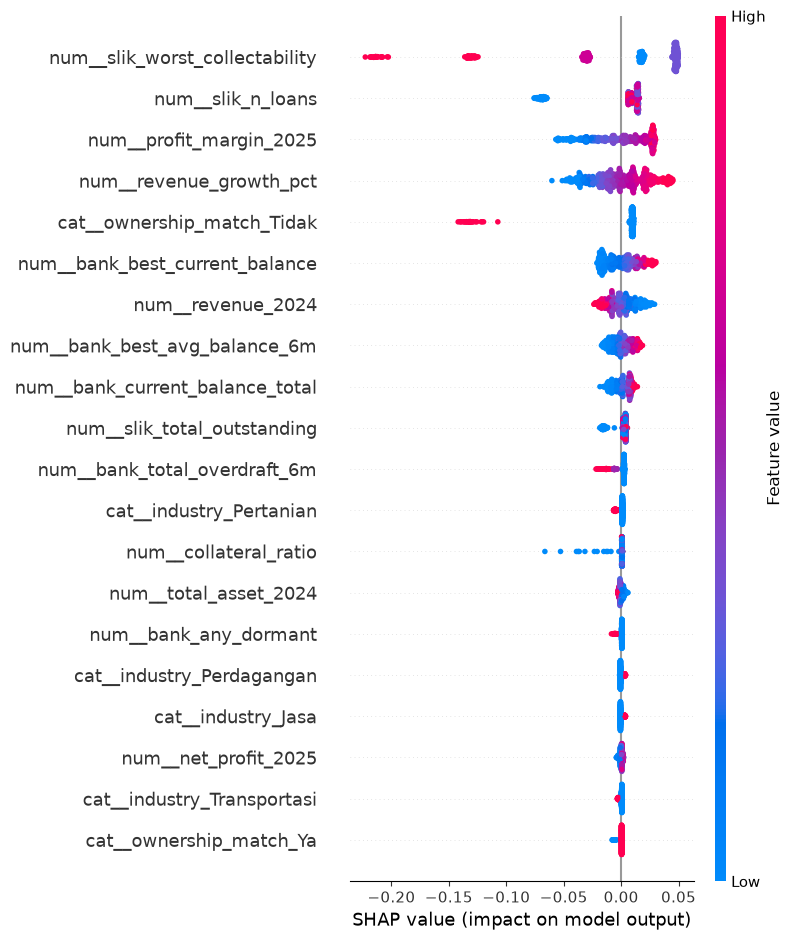

In [13]:
if best_name in ("XGBoost", "Random Forest"):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_proc)
    shap_values.feature_names = list(feature_names)
    shap.summary_plot(shap_values, feature_names=feature_names, show=True)
else:
    coefs = pd.Series(best_model.coef_, index=feature_names).sort_values(key=abs, ascending=False)
    print("Top 15 fitur berdasarkan |koefisien| (standardized):")
    print(coefs.head(15))

In [14]:
if best_name in ("XGBoost", "Random Forest"):
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    fi = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(15)
    print("Top 15 fitur berdasarkan mean|SHAP value|:")
    print(fi.to_string())

Top 15 fitur berdasarkan mean|SHAP value|:
num__slik_worst_collectability     0.051869
num__slik_n_loans                  0.022990
num__profit_margin_2025            0.020310
num__revenue_growth_pct            0.018682
cat__ownership_match_Tidak         0.016814
num__bank_best_current_balance     0.012120
num__revenue_2024                  0.009203
num__bank_best_avg_balance_6m      0.006891
num__bank_current_balance_total    0.005986
num__slik_total_outstanding        0.005569
num__bank_total_overdraft_6m       0.004096
cat__industry_Pertanian            0.001745
num__collateral_ratio              0.001398
num__total_asset_2024              0.001345
num__bank_any_dormant              0.001019


## Tahap 7 — Ekspor Model + Preprocessor

Disimpan dengan nama jelas (`risk_score_*`, beda namespace dari
`credit_model.pkl` lama yang menargetkan `label`, bukan `risk_score`) —
plus arsip per-timestamp untuk audit ulang, sama seperti pola di
`03_model_training.ipynb`.

In [15]:
import os
from datetime import datetime
os.makedirs(MODEL_DIR, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

meta = {
    "model_name": best_name,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "feature_names_encoded": list(feature_names),
    "target": "risk_score",
    "policy_definition": "Definisi A (notebooks/02_prepro&eda fix.ipynb / master_scored.csv)",
    "decision_thresholds": {"Layak": 0.70, "Layak Bersyarat": 0.55, "Perlu Review Ulang": 0.40},
    "train_timestamp": ts,
    "test_metrics": summary[summary["Model"] == best_name].to_dict("records")[0],
}

joblib.dump(preprocessor, f"{MODEL_DIR}/risk_score_preprocessor_{ts}.pkl")
joblib.dump(best_model, f"{MODEL_DIR}/risk_score_model_{ts}.pkl")
joblib.dump(meta, f"{MODEL_DIR}/risk_score_meta_{ts}.pkl")

# Stable-named copies -> dipanggil oleh utils/risk_ml_pipeline.py
joblib.dump(preprocessor, f"{MODEL_DIR}/risk_score_preprocessor.pkl")
joblib.dump(best_model, f"{MODEL_DIR}/risk_score_model.pkl")
joblib.dump(meta, f"{MODEL_DIR}/risk_score_meta.pkl")

summary.to_csv(f"{MODEL_DIR}/risk_score_model_comparison.csv", index=False)

print(f"Tersimpan (arsip run {ts}): risk_score_model_{ts}.pkl, risk_score_preprocessor_{ts}.pkl, risk_score_meta_{ts}.pkl")
print("Tersimpan (nama stabil, dipakai utils/risk_ml_pipeline.py): risk_score_model.pkl, risk_score_preprocessor.pkl, risk_score_meta.pkl")
print("Tersimpan: risk_score_model_comparison.csv")

Tersimpan (arsip run 20260825_163612): risk_score_model_20260825_163612.pkl, risk_score_preprocessor_20260825_163612.pkl, risk_score_meta_20260825_163612.pkl
Tersimpan (nama stabil, dipakai utils/risk_ml_pipeline.py): risk_score_model.pkl, risk_score_preprocessor.pkl, risk_score_meta.pkl
Tersimpan: risk_score_model_comparison.csv


## Tahap 8 — Perbandingan Rule-Based Lama vs ML Baru (apple-to-apple)

Perbandingan langsung MAE/RMSE terhadap rule-based lama tidak bermakna
(rule-based IS `risk_score`, jadi errornya otomatis 0 terhadap dirinya
sendiri). Perbandingan yang bermakna: **seberapa dekat masing-masing
pendekatan terhadap `label` ground truth asli dari generator**
(`Diterima`/`Ditolak`) — metrik independen yang tidak terlibat langsung di
pembuatan `risk_score` rule maupun di training ML.

In [16]:
# Skor SEMUA baris (termasuk yang kena hard-rule) dengan ML, untuk perbandingan apple-to-apple
X_all = df[FEATURES]
ml_score_all = np.clip(best_model.predict(preprocessor.transform(X_all)), 0, 1)
df["ml_risk_score"] = ml_score_all
df["ml_decision"] = np.where(df["risk_score"].isna(), "Tidak Layak", df["ml_risk_score"].apply(score_to_decision))

df["label_diterima"] = df["label"] == "Diterima"
rule_agree = (df["decision"].isin(["Layak", "Layak Bersyarat"]) == df["label_diterima"]).mean()
ml_agree = (df["ml_decision"].isin(["Layak", "Layak Bersyarat"]) == df["label_diterima"]).mean()

comparison = pd.DataFrame({
    "Pendekatan": ["Rule-based (Definisi A, formula manual)", "ML risk_score + policy engine (Layer 1+2)"],
    "Agreement vs label asli": [rule_agree, ml_agree],
})
print(comparison.to_string(index=False))
print()
print(f"Rule-based : {rule_agree:.1%}")
print(f"ML hybrid  : {ml_agree:.1%}")
print(f"Selisih    : {(ml_agree - rule_agree)*100:+.2f} poin persentase")

                               Pendekatan  Agreement vs label asli
  Rule-based (Definisi A, formula manual)                 0.926667
ML risk_score + policy engine (Layer 1+2)                 0.928333

Rule-based : 92.7%
ML hybrid  : 92.8%
Selisih    : +0.17 poin persentase


## Ringkasan

- **Feature engineering**: 46 fitur mentah (39 numerik + 7 kategorikal) dari
  `master_dataset.csv`, tanpa rule-derived score, leakage, kolom RM, atau
  fitur sensitif gender/status pernikahan.
- **Hard-rule filtering**: baris yang kena kill-switch (identity/DHN/SLIK
  Macet) dibuang dari training (~7,3% data) — hard rule tetap dijalankan
  duluan saat inference, model ML hanya menangani kasus yang lolos.
- **3 model dibandingkan**; model dengan RMSE terendah dipilih untuk
  deployment (lihat tabel Tahap 5 untuk model yang terpilih pada run ini).
- **Explainability**: SHAP (tree-based) / koefisien (linear) menunjukkan
  fitur SLIK, margin laba, dan pertumbuhan omset sebagai kontributor
  terbesar — selaras dengan bobot Character & Financial yang memang
  terbesar di rule lama, meski model tidak pernah diberi tahu bobot itu.
- **Perbandingan apple-to-apple** (Tahap 8): pipeline ML+rule mempertahankan
  tingkat kesesuaian dengan `label` ground truth asli yang sebanding dengan
  rule-based manual — ML berhasil mereplikasi kualitas keputusan tanpa
  diberi tahu formula.
- **Artifact tersimpan** di `../models/risk_score_*.pkl`, siap dipanggil
  lewat `utils/risk_ml_pipeline.py::predict_credit_screening()`.
- **Belum diwire ke `app.py`**: mengganti `utils/agent_pipeline.py` (live,
  Definisi B) dengan pipeline ini akan mengubah angka `decision`/`zone`/
  `bunga_persen` yang tampil di dashboard (beda threshold/bobot) — perlu
  keputusan eksplisit terpisah sebelum dilakukan.